<a href="https://colab.research.google.com/github/dhileepan-ai-engineering/pdf-content-extractor/blob/main/PDFParsing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting Up Your Google Colab Environment

In [1]:
!pip install -q pdfplumber pymupdf pillow pydantic google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 35.8 MB/s eta 0:00:00


## Extracting All Text and Bounding Boxes

In [3]:
import pdfplumber

def extract_text_from_pdf(pdf_path):
  with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start =1):
      text = page.extract_text()
      #print(text[:500])

      words = page.extract_words()
      print(words[:5])

extract_text_from_pdf("BMW.pdf")

[{'text': 'THE', 'x0': 621.2608, 'x1': 730.4608000000001, 'top': 666.7895000000001, 'doctop': 666.7895000000001, 'bottom': 719.2895, 'upright': True, 'height': 52.499999999999886, 'width': 109.20000000000005, 'direction': 'ltr'}, {'text': 'X3', 'x0': 746.02705, 'x1': 809.18455, 'top': 666.7895000000001, 'doctop': 666.7895000000001, 'bottom': 719.2895, 'upright': True, 'height': 52.499999999999886, 'width': 63.157499999999914, 'direction': 'ltr'}, {'text': 'M', 'x0': 826.58305, 'x1': 872.4155499999999, 'top': 666.7895000000001, 'doctop': 666.7895000000001, 'bottom': 719.2895, 'upright': True, 'height': 52.499999999999886, 'width': 45.83249999999998, 'direction': 'ltr'}, {'text': 'For', 'x0': 47.2252, 'x1': 58.4252, 'top': 770.2359, 'doctop': 770.2359, 'bottom': 777.2359, 'upright': True, 'height': 7.0, 'width': 11.199999999999996, 'direction': 'ltr'}, {'text': 'more', 'x0': 59.9302, 'x1': 77.0725, 'top': 770.2359, 'doctop': 770.2359, 'bottom': 777.2359, 'upright': True, 'height': 7.0, '

In [5]:
import pdfplumber

def extract_text_from_pdf(pdf_path, search_term):
  with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start = 1):
      text = page.extract_text()

      if text and search_term.lower() in text.lower():

        for line in text.split("\n"):
          if search_term.lower() in line.lower():
            print(f" -> {line.strip()}")

extract_text_from_pdf("BMW.pdf","car")

 ->  The specific model designation of the BMW X3 M is located  The M seat belts* with belt tensioner and belt force limiter have  The high-performance BMW M TwinPower Turbo inline  The M Carbon precision strut increases frontend rigidity and
 -> specific gear selector.1 smooth running coupled with a sporty engine sound. With Double- premium quality carbon fibre reinforced polymer component is
 -> BMW M performance Air Duct Trim in Carbon Fibre. BMW M Performance Fuel Filler Cap in Carbon Fiber.
 -> BMW M Performance Kidney Grille, Carbon. The frame of the BMW M Performance front grille is made of premium carbon fibre. For an
 -> BMW M performance Key Case in Alcantara and Carbon Fibre. BMW M Performance Floor Mats, Front and Rear. The BMW M
 -> BMW M Performance Exterior Mirror Cap in Carbon Fibre. BMW M performance Motorsport Decals. The BMW M
 -> appearance of the car’s interior.
 -> M Performance Air Breather in Carbon Fibre. BMW M performance Steering Wheel in Alcantara and Ca

## Extracting Tables

In [6]:
import pdfplumber
import pandas as pd

def extract_tables_from_pdf(pdf_path):
  tables_found = []
  with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages, start = 1):
      extracted_tables = page.extract_tables()

      for idx, table in enumerate(extracted_tables):
        df = pd.DataFrame(table)
        print(df.head())
        tables_found.append(df)
  return tables_found

extract_tables_from_pdf("BMW.pdf")

                0
0                
1  15\nHighlights
                              0
0                              
1  19\nOriginal BMW Accessories
                    0
0                    
1  21\nTechnical data
                                                   0
0                                                   
1  BMW M Performance Kidney Grille, Carbon. The f...
                                                  0
0                                                  
1  BMW M performance Air Duct Trim in Carbon Fibre.
                                                   0
0                                                   
1  BMW M Performance Fuel Filler Cap in Carbon Fi...
                                                   0
0                                                   
1  BMW M performance Key Case in Alcantara and Ca...
                                                   0
0                                                   
1  BMW M Performance Floor Mats, Front and Re

[                0
 0                
 1  15\nHighlights,
                               0
 0                              
 1  19\nOriginal BMW Accessories,
                     0
 0                    
 1  21\nTechnical data,
                                                    0
 0                                                   
 1  BMW M Performance Kidney Grille, Carbon. The f...,
                                                   0
 0                                                  
 1  BMW M performance Air Duct Trim in Carbon Fibre.,
                                                    0
 0                                                   
 1  BMW M Performance Fuel Filler Cap in Carbon Fi...,
                                                    0
 0                                                   
 1  BMW M performance Key Case in Alcantara and Ca...,
                                                    0
 0                                                   
 1  BMW M Perfo

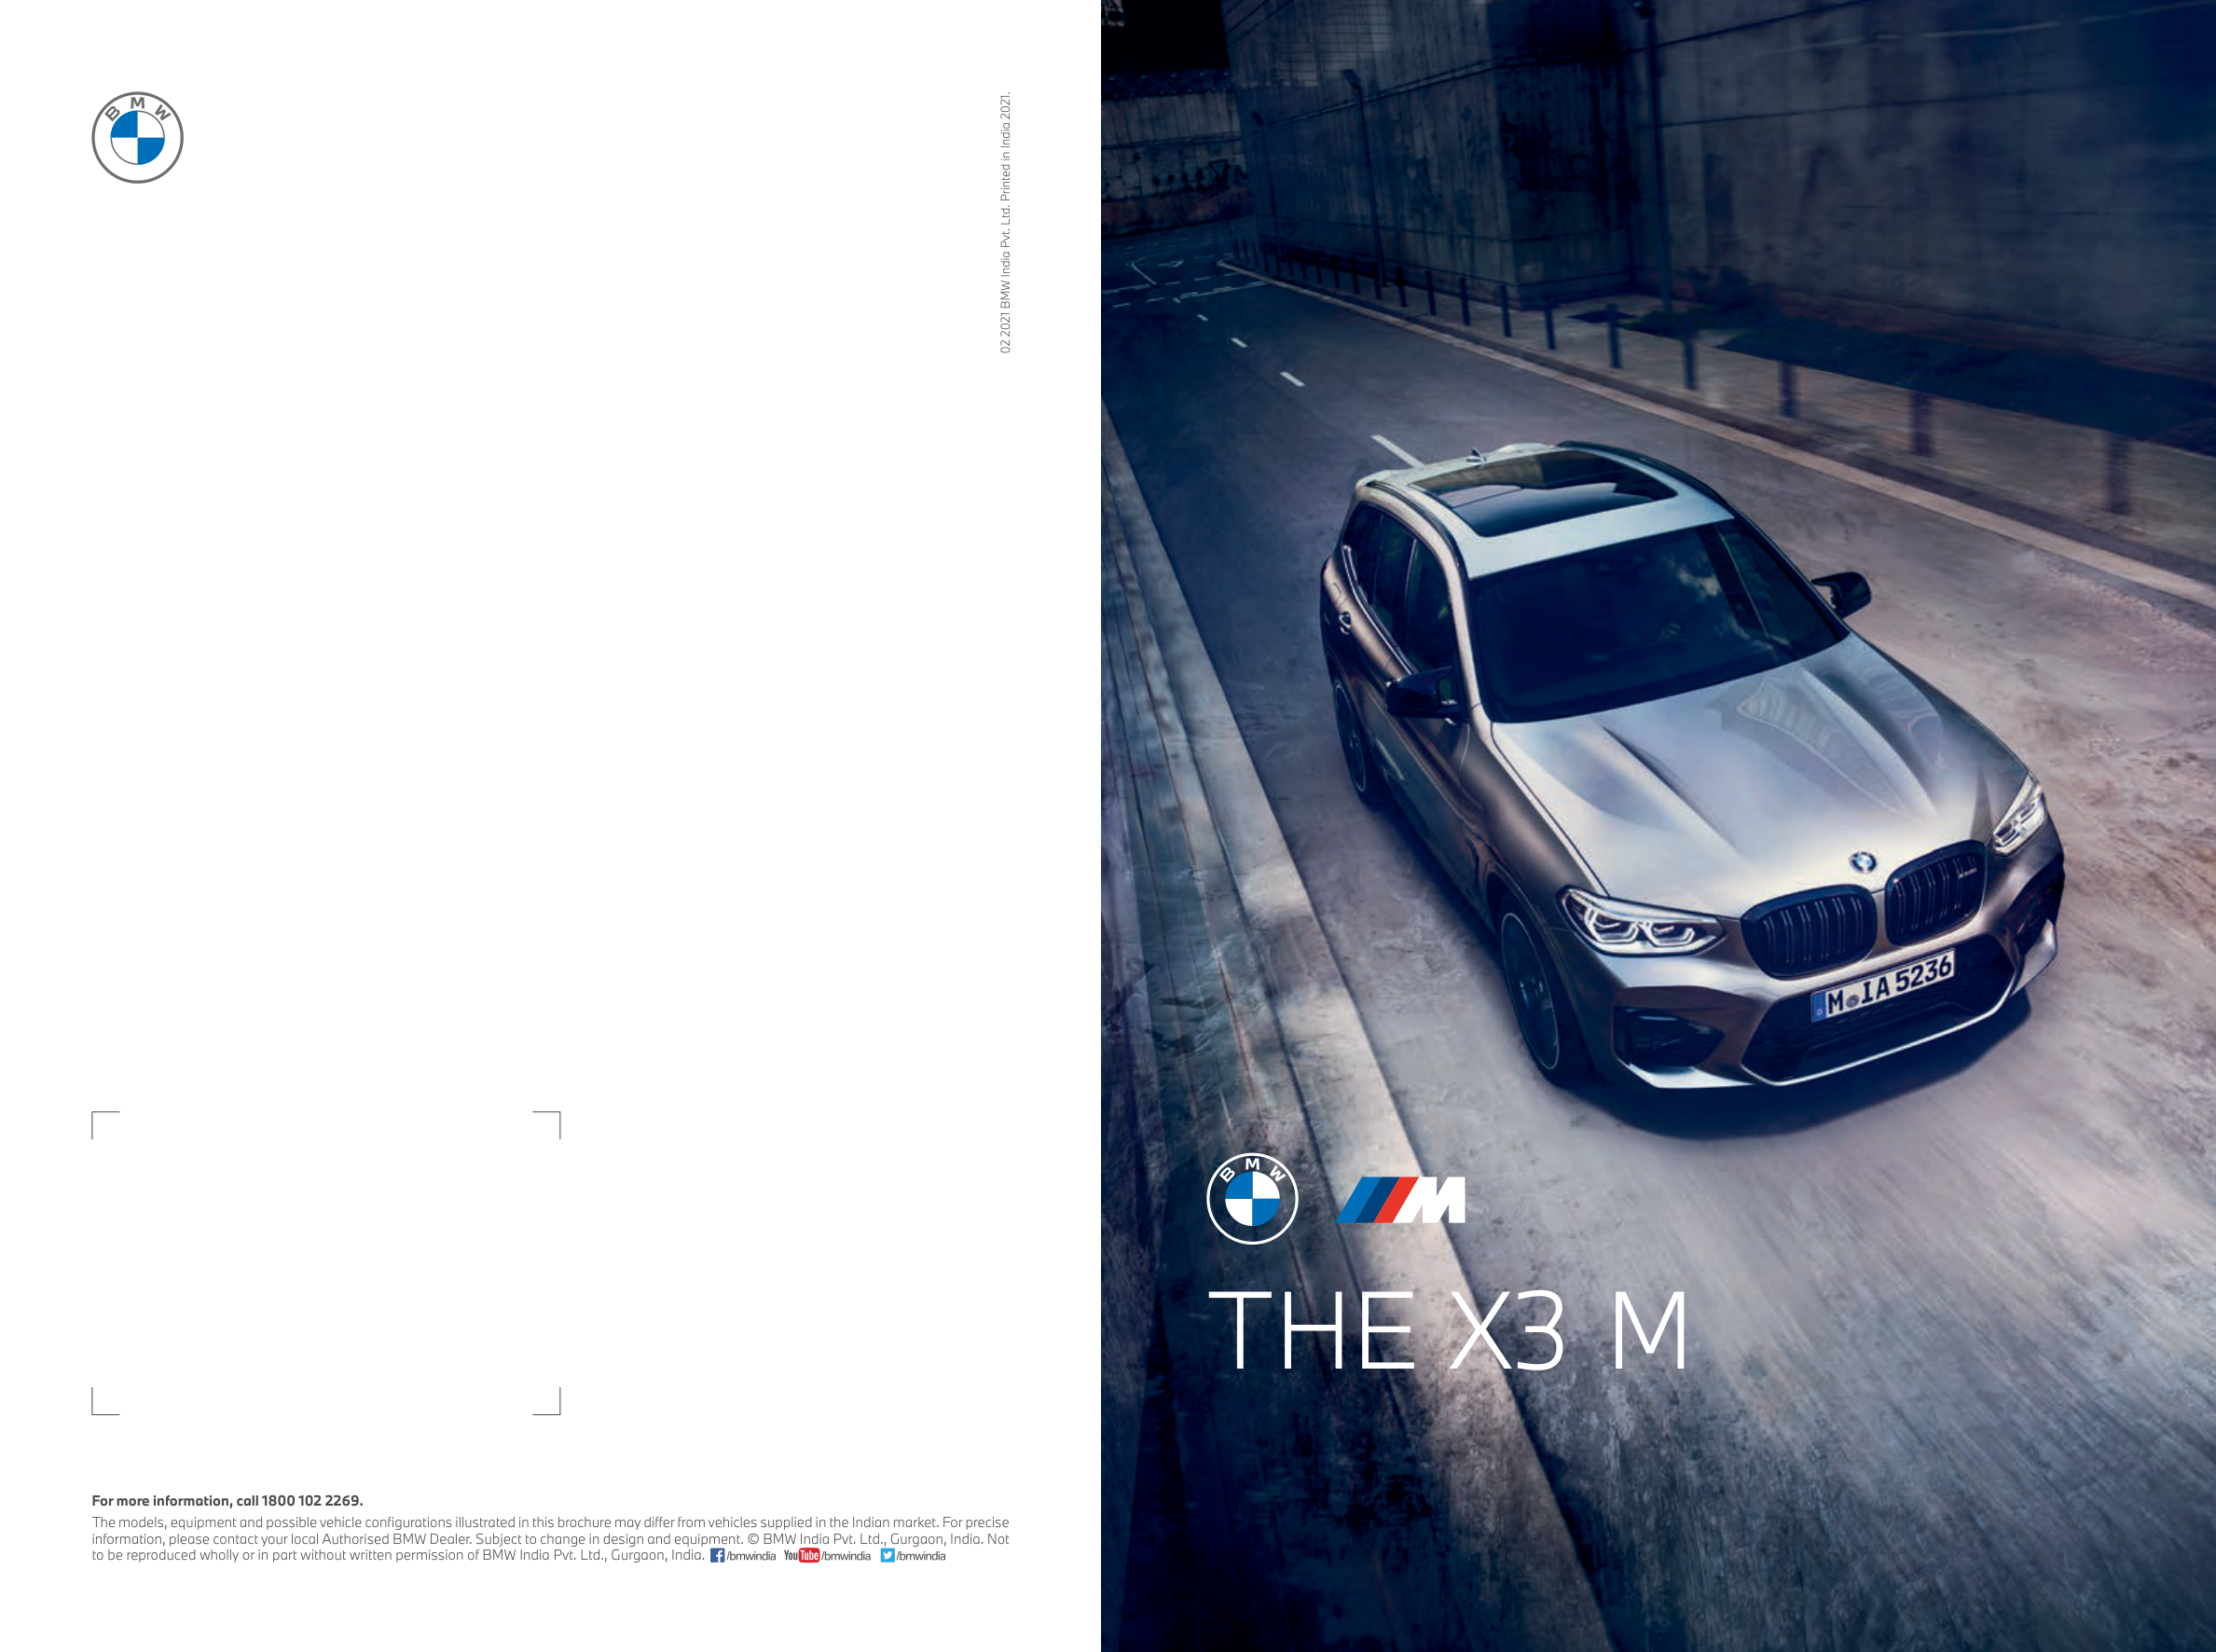

In [7]:
import pymupdf
from PIL import Image
import io

def convert_pdf_to_image(pdf_path, page_number = 0,dpi=150):
  doc = pymupdf.open(pdf_path)
  page = doc.load_page(page_number)
  pix = page.get_pixmap(dpi=dpi)
  img = Image.open(io.BytesIO(pix.tobytes("png")))
  return img

convert_pdf_to_image("BMW.pdf")

In [8]:
import pymupdf
from PIL import Image
import io

import os
from google.colab import userdata

from google import genai
from google.genai import types
from pydantic import BaseModel, Field

import json

def convert_pdf_to_image(pdf_path,page_number=9,dpi=150):
  doc = pymupdf.open(pdf_path)
  page = doc.load_page(page_number)
  pix = page.get_pixmap(dpi=dpi)
  return Image.open(io.BytesIO(pix.tobytes("png")))

img = convert_pdf_to_image("BMW.pdf")

os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

client = genai.Client()

class CarBrochureSchema(BaseModel):
  starting_price: str = Field(description="Starting price of car mentioned in the document")
  highlights: str = Field(description="Fetch the text present under the sub-sections of the section named 'HIGHLIGHTS.'")

def parse_brochure_with_vision(pdf_image):
  prompt = """
  You are an expert Document parsing AI. Analyze the document. Extract all the key information accurately.
  If looked information is not found in the document, return 'Not Found'.
  """

  response = client.models.generate_content(
      model = "gemini-2.5-flash",
      contents = [pdf_image, prompt],
      config = types.GenerateContentConfig(
          response_mime_type = "application/json",
          response_schema = CarBrochureSchema,
          temperature = 0.0
      ),
  )

  return response.text

result_json = parse_brochure_with_vision(img)

parsed_data = json.loads(result_json)
print(json.dumps(parsed_data, indent=2))

{
  "starting_price": "Not Found",
  "highlights": "The Adaptive LED headlights include low-beam and high-beam headlights and turn indicators with full LED technology. The equipment also features BMW Selective Beam, cornering lights, daytime running lights and Adaptive headlights with variable light control for excellent illumination of the road ahead and better visibility in the dark.Thanks to the use of various materials, M Compound brakes achieve outstanding deceleration values and are extremely stable and highly durable. They also weigh less, which has a positive impact on agility, dynamics and acceleration. The Blue metallic brake callipers with the M designation are the hallmark of these high-performance M specific brakes.The red Start/Stop button allows the engine to be started without using the key once the vehicle has been unlocked. It can also be used to stop the engine. The vehicle key is recognised automatically, without having to insert it.The M leather steering wheel incl